# Classification du Sentiment envers le Président — Archelec

Ce notebook développe deux pipelines de classification pour déterminer si une phrase de tract électoral exprime un sentiment **positif** ou **négatif** à l'égard du président en exercice.

| Pipeline | Représentation | Classifieur | Imbalance |
|---|---|---|---|
| 1 | TF-IDF (1-2grammes) | XGBoost | SMOTE + scale_pos_weight |
| 2 | CamemBERT `[CLS]` | CatBoost | SMOTE + class_weights |

**Données**: 200 exemples annotés manuellement (186 positifs / 14 négatifs), 6 142 à prédire.


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import torch
from transformers import AutoTokenizer, AutoModel

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42


## 1. Chargement et exploration des données

In [128]:
import re

DATA_PATH = '../../data/results/output_best_model/leaders_mentions.xlsx'
df = pd.read_excel(DATA_PATH)
print(f'Shape brut : {df.shape}')

# ── Déduplication sur le texte (avant toute analyse) ─────────────────────────
# Si deux lignes ont le même texte (après nettoyage des marqueurs), on garde :
#   1. La ligne annotée (gold label)          → priorité +2
#   2. Sinon celle avec un vrai nom de parti  → priorité +1
def _norm(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\[([^\]]*)\]', r'\1', text)  # enlever marqueurs [...]
    return re.sub(r'\s+', ' ', text).strip()

parti_vide = {'non mentionné', 'inconnu', ''}
df['_tnorm']    = df['text'].apply(_norm)
df['_priority'] = (
    df['sentiment_president'].notna().astype(int) * 2 +
    (~df['parti'].str.strip().str.lower().isin(parti_vide)).astype(int)
)
n_before = len(df)
df = (
    df.sort_values('_priority', ascending=False)
      .drop_duplicates(subset='_tnorm', keep='first')
      .drop(columns=['_priority', '_tnorm'])
      .reset_index(drop=True)
)
print(f'Shape après déduplication : {df.shape}')
print(f'Doublons supprimés        : {n_before - len(df)}  ({n_before} → {len(df)} lignes)')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)

Shape brut : (6342, 8)
Shape après déduplication : (4864, 8)
Doublons supprimés        : 1478  (6342 → 4864 lignes)
Colonnes : ['annee', 'departement', 'parti', 'file_id', 'entite', 'actual_president', 'text', 'sentiment_president']


,annee,departement,parti,file_id,entite,actual_president,text,sentiment_president
0,1973,Pas-de-Calais,Alliance républicaine indépendante et libérale,EL067_L_1973_03_062_04_1_PF_07,Georges Pompidou,Georges Pompidou,Sciences Po / fonds CEVIPOF\n4e circonscriptio...,positif
1,1973,Marne,Union des républicains de progrès;Union des dé...,EL067_L_1973_03_051_01_1_PF_04,Georges POMPIDOU,Georges Pompidou,tion. L'enjeu de ces élections est important. ...,positif
2,1973,Marne,Alliance républicaine indépendante et libérale,EL067_L_1973_03_051_02_1_PF_05,Georges Pompidou,Georges Pompidou,Sciences Po / fonds CEVIPOF\n2e circonscriptio...,positif


In [129]:
labeled   = df[df['sentiment_president'].notna()].copy()   # 200 annotés
unlabeled = df[df['sentiment_president'].isna()].copy()    # 6142 à prédire

print(f'Exemples annotés : {len(labeled)}')
print(f'Exemples non-annotés : {len(unlabeled)}')
print()
print('Distribution des labels:')
print(labeled['sentiment_president'].value_counts())
print(f"\nRatio déséquilibre positif:négatif = "
      f"{(labeled['sentiment_president']=='positif').sum()}"
      f":{(labeled['sentiment_president']=='négatif').sum()}")


Exemples annotés : 197
Exemples non-annotés : 4667

Distribution des labels:
sentiment_president
positif    186
négatif     11
Name: count, dtype: int64

Ratio déséquilibre positif:négatif = 186:11


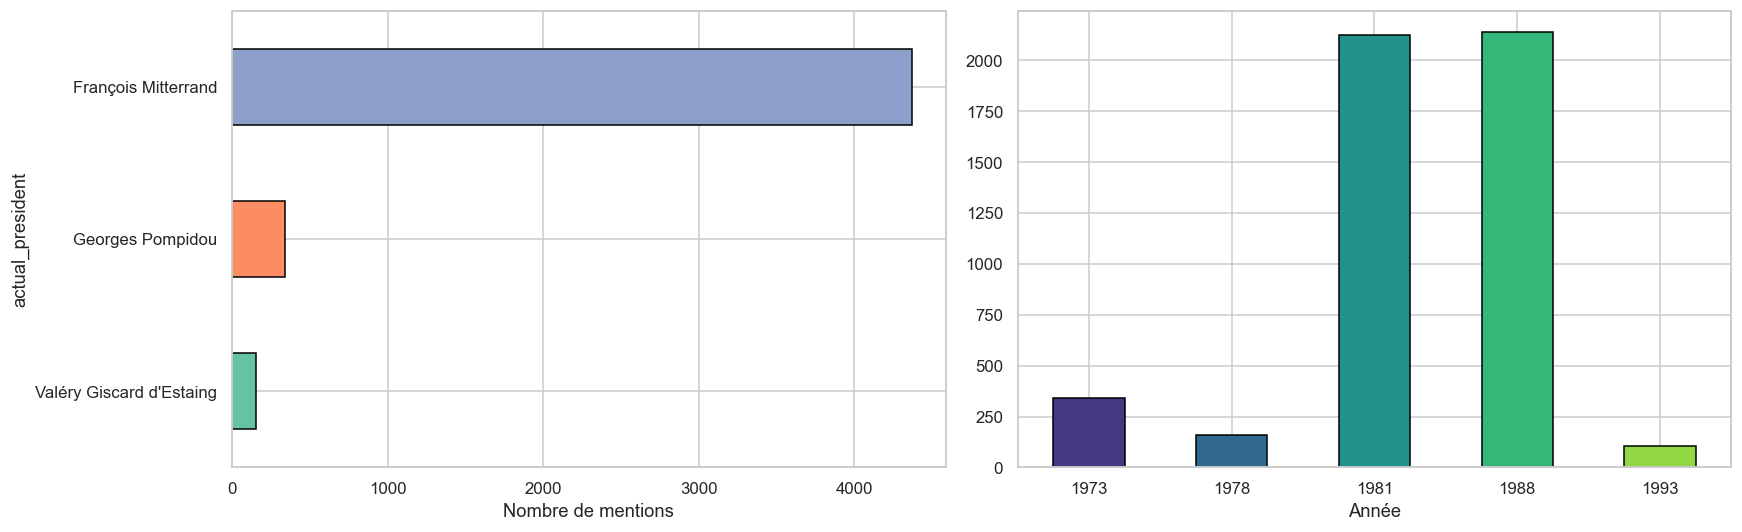

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # --- 1) Distribution des labels ---
# counts = labeled['sentiment_president'].value_counts()
# bars = axes[0].bar(counts.index, counts.values,
#                    color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
# for bar in bars:
#     axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
#                  str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=12)
# # axes[0].set_title('Distribution des labels (200 exemples)', fontweight='bold')
# axes[0].set_ylabel('Nombre')
# axes[0].set_ylim(0, 210)

# --- 2) Mentions totales par année ---
year_counts = df.groupby('annee').size()
year_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('viridis', len(year_counts)),
                  edgecolor='black')
# axes[1].set_title('Mentions totales par année', fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].tick_params(axis='x', rotation=0)

# --- 3) Mentions par président ---
pres_counts = df.groupby('actual_president').size().sort_values(ascending=True)
pres_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', len(pres_counts)),
                  edgecolor='black')
# axes[2].set_title('Mentions par président en exercice', fontweight='bold')
axes[0].set_xlabel('Nombre de mentions')

plt.tight_layout()
plt.show()


## 2. Préparation des données

In [131]:
def preprocess_text(text):
    if pd.isna(text):
        return ''
    # Supprimer les marqueurs d'entité [...]
    text = re.sub(r'\[([^\]]*)\]', r'\1', text)
    # Normaliser les espaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(preprocess_text)

# Recalculer labeled / unlabeled (df déjà dédupliqué au chargement)
labeled   = df[df['sentiment_president'].notna()].copy()
unlabeled = df[df['sentiment_president'].isna()].copy()
print(f'Annotés  : {len(labeled)}  |  Non-annotés : {len(unlabeled)}')

# ── Mots vides français ───────────────────────────────────────────────────────
FRENCH_STOPWORDS = list(set([
    # Articles définis / indéfinis / contractés
    'le', 'la', 'les', 'l', 'un', 'une', 'des', 'au', 'aux', 'du',
    # Prépositions
    'de', 'd', 'en', 'à', 'par', 'pour', 'sur', 'sous', 'dans', 'avec',
    'sans', 'entre', 'vers', 'chez', 'contre', 'depuis', 'après', 'avant',
    'pendant', 'selon', 'malgré', 'sauf', 'lors', 'jusque', 'dès',
    # Pronoms personnels & réfléchis
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'on',
    'me', 'te', 'se', 'lui', 'y',
    # Pronoms & adjectifs possessifs
    'mon', 'ton', 'son', 'ma', 'ta', 'sa', 'notre', 'votre', 'leur', 'leurs',
    'mes', 'tes', 'ses', 'nos', 'vos',
    # Démonstratifs
    'ce', 'cet', 'cette', 'ces', 'cela', 'ça', 'ceci',
    # Conjonctions & pronoms relatifs
    'et', 'ou', 'ni', 'mais', 'donc', 'or', 'car',
    'que', 'qui', 'quoi', 'dont', 'où', 'quand',
    'si', 'comme', 'parce', 'lorsque', 'puisque', 'bien',
    # Auxiliaires et verbes très courants
    'est', 'sont', 'était', 'étaient', 'être', 'avoir', 'ont', 'été',
    'sera', 'seront', 'serait', 'seraient',
    'a', 'ai', 'as', 'avons', 'avez', 'avait',
    'fait', 'faire', 'peut', 'peuvent', 'doit', 'doivent',
    # Adverbes fréquents sans portée sémantique forte
    'ne', 'pas', 'plus', 'très', 'tout', 'tous', 'toute', 'toutes',
    'aussi', 'alors', 'ainsi', 'déjà', 'encore', 'même', 'jamais',
    'toujours', 'souvent', 'non', 'oui', 'trop', 'peu', 'voilà', 'voici',
    # Lettres isolées (résidus de tokenisation TF-IDF)
    'j', 'n', 'c', 's', 'm', 'qu',
]))
print(f'{len(FRENCH_STOPWORDS)} mots vides définis')

# ── Encodage des labels & préparation CV ─────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(labeled['sentiment_president'])   # négatif=0, positif=1
X_text = labeled['text_clean'].values

print(f'Classes : {le.classes_}  →  0=négatif, 1=positif')
print(f'Distribution : {Counter(y)}')
print(f'Ratio pos:neg = {(y==1).sum()}:{(y==0).sum()}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('\nPréparation terminée')

Annotés  : 197  |  Non-annotés : 4667
143 mots vides définis
Classes : ['négatif' 'positif']  →  0=négatif, 1=positif
Distribution : Counter({np.int64(1): 186, np.int64(0): 11})
Ratio pos:neg = 186:11

Préparation terminée


## 3. Pipeline 1 — TF-IDF + XGBoost

- **TF-IDF** : 10 000 features, bi-grammes, `sublinear_tf=True`
- **Déséquilibre** : SMOTE à l'intérieur de chaque fold + `scale_pos_weight` dans XGBoost
- **Évaluation** : cross-validation 5-fold stratifiée


In [132]:
scale_pw = (y == 0).sum() / (y == 1).sum()   # ~13.3
print(f'scale_pos_weight = {scale_pw:.2f}')

y_pred_cv1 = np.zeros(len(y), dtype=int)
y_prob_cv1 = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_text, y)):
    X_tr, X_val = X_text[train_idx], X_text[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # TF-IDF fit on train (stopwords français exclus)
    tfidf = TfidfVectorizer(
        max_features=10000, ngram_range=(1, 2),
        min_df=1, sublinear_tf=True,
        stop_words=FRENCH_STOPWORDS
    )
    X_tr_tfidf  = tfidf.fit_transform(X_tr)
    X_val_tfidf = tfidf.transform(X_val)

    # SMOTE — k_neighbors adapté à la taille du fold
    k = max(1, min(5, (y_tr == 0).sum() - 1))
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_tfidf, y_tr)

    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.08,
        scale_pos_weight=scale_pw,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
    )
    xgb.fit(X_tr_sm, y_tr_sm)

    y_pred_cv1[val_idx] = xgb.predict(X_val_tfidf)
    y_prob_cv1[val_idx] = xgb.predict_proba(X_val_tfidf)[:, 1]

print('=== Pipeline 1 : TF-IDF + XGBoost (CV 5-fold) ===')
print(classification_report(y, y_pred_cv1, target_names=le.classes_))
print(f'ROC-AUC            : {roc_auc_score(y, y_prob_cv1):.4f}')
print(f'Balanced Accuracy  : {balanced_accuracy_score(y, y_pred_cv1):.4f}')

scale_pos_weight = 0.06
=== Pipeline 1 : TF-IDF + XGBoost (CV 5-fold) ===
              precision    recall  f1-score   support

     négatif       1.00      0.18      0.31        11
     positif       0.95      1.00      0.98       186

    accuracy                           0.95       197
   macro avg       0.98      0.59      0.64       197
weighted avg       0.96      0.95      0.94       197

ROC-AUC            : 0.8118
Balanced Accuracy  : 0.5909


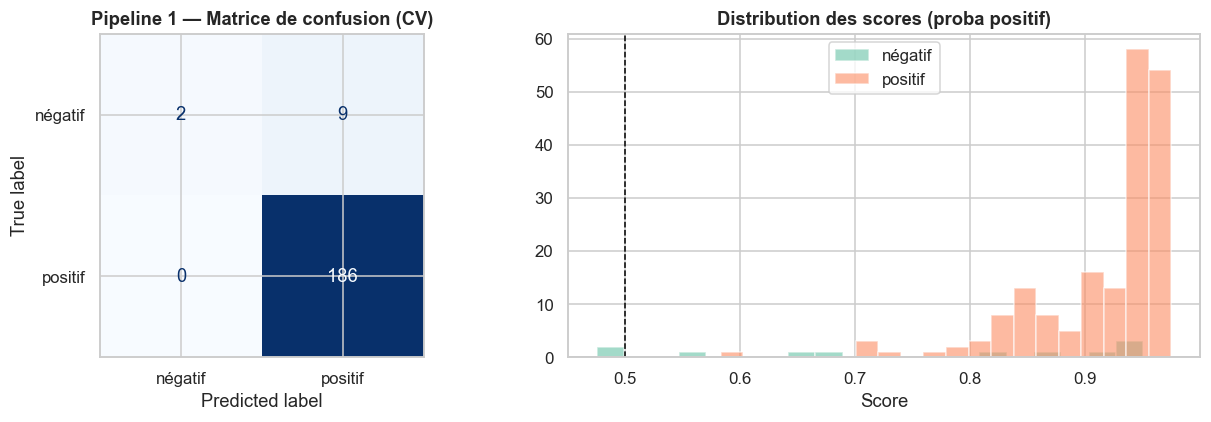

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y, y_pred_cv1),
    display_labels=le.classes_
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Pipeline 1 — Matrice de confusion (CV)', fontweight='bold')

# Score distribution
for cls, lbl in zip([0, 1], le.classes_):
    axes[1].hist(y_prob_cv1[y == cls], bins=20, alpha=0.6, label=lbl)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution des scores (proba positif)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Pipeline 2 — CamemBERT + CatBoost

- **Embeddings** : vecteur `[CLS]` de `camembert-base` (768 dimensions, max 256 tokens)
- **Déséquilibre** : SMOTE sur les embeddings + `class_weights` dans CatBoost
- Accélération MPS (Apple Silicon) si disponible


In [134]:
MODEL_NAME = 'camembert-base'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
camembert  = AutoModel.from_pretrained(MODEL_NAME)
camembert.eval()

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
camembert = camembert.to(device)
print(f'CamemBERT chargé sur : {device}')

def get_embeddings(texts, batch_size=32, max_length=256):
    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=max_length, return_tensors='pt')
        enc   = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = camembert(**enc)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_emb.append(cls)
    return np.vstack(all_emb)

print('Extraction des embeddings (train, 200 exemples)...')
X_emb = get_embeddings(X_text)
print(f'Shape embeddings : {X_emb.shape}')   # (200, 768)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CamemBERT chargé sur : mps
Extraction des embeddings (train, 200 exemples)...
Shape embeddings : (197, 768)


In [135]:
n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
cw_neg, cw_pos = 1.0, n_neg / n_pos
print(f'Class weights — négatif: {cw_neg:.1f}, positif: {cw_pos:.2f}')

y_pred_cv2 = np.zeros(len(y), dtype=int)
y_prob_cv2 = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_emb, y)):
    X_tr_e, X_val_e = X_emb[train_idx], X_emb[val_idx]
    y_tr = y[train_idx]

    k = max(1, min(5, (y_tr == 0).sum() - 1))
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_e, y_tr)

    w_pos_fold = (y_tr == 0).sum() / (y_tr == 1).sum()
    cat = CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        loss_function='Logloss',
        class_weights=[1.0, w_pos_fold],
        random_seed=RANDOM_STATE, verbose=0
    )
    cat.fit(X_tr_sm, y_tr_sm)

    y_pred_cv2[val_idx] = cat.predict(X_val_e)
    y_prob_cv2[val_idx] = cat.predict_proba(X_val_e)[:, 1]

print('=== Pipeline 2 : CamemBERT + CatBoost (CV 5-fold) ===')
print(classification_report(y, y_pred_cv2, target_names=le.classes_))
print(f'ROC-AUC            : {roc_auc_score(y, y_prob_cv2):.4f}')
print(f'Balanced Accuracy  : {balanced_accuracy_score(y, y_pred_cv2):.4f}')


Class weights — négatif: 1.0, positif: 0.06
=== Pipeline 2 : CamemBERT + CatBoost (CV 5-fold) ===
              precision    recall  f1-score   support

     négatif       0.30      0.27      0.29        11
     positif       0.96      0.96      0.96       186

    accuracy                           0.92       197
   macro avg       0.63      0.62      0.62       197
weighted avg       0.92      0.92      0.92       197

ROC-AUC            : 0.7160
Balanced Accuracy  : 0.6175


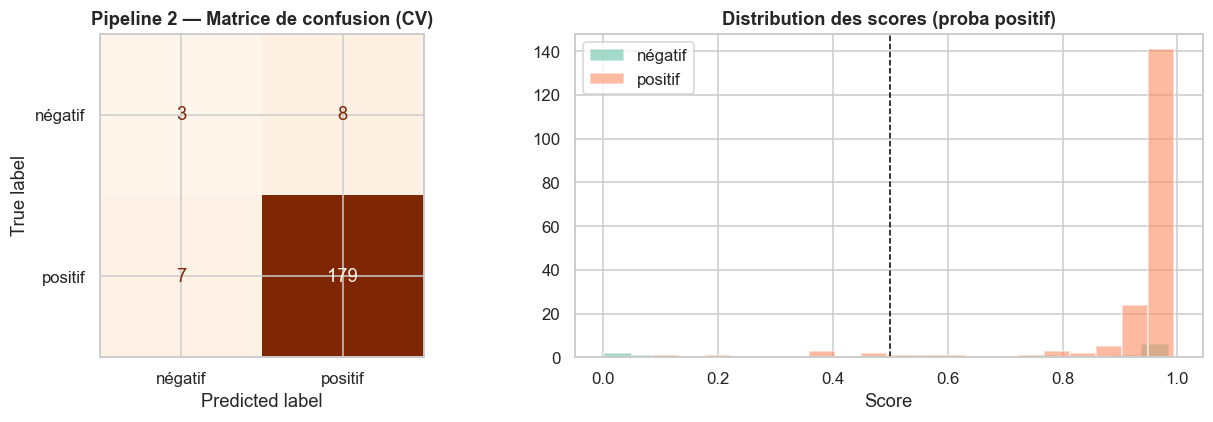

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y, y_pred_cv2),
    display_labels=le.classes_
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Pipeline 2 — Matrice de confusion (CV)', fontweight='bold')

for cls, lbl in zip([0, 1], le.classes_):
    axes[1].hist(y_prob_cv2[y == cls], bins=20, alpha=0.6, label=lbl)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution des scores (proba positif)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Comparaison des deux pipelines

,F1-négatif,F1-positif,F1-macro,ROC-AUC,Balanced Acc.
Pipeline,,,,,
TF-IDF + XGBoost,0.307700,0.976400,0.642000,0.811800,0.590900
CamemBERT + CatBoost,0.285700,0.959800,0.622700,0.716000,0.617500


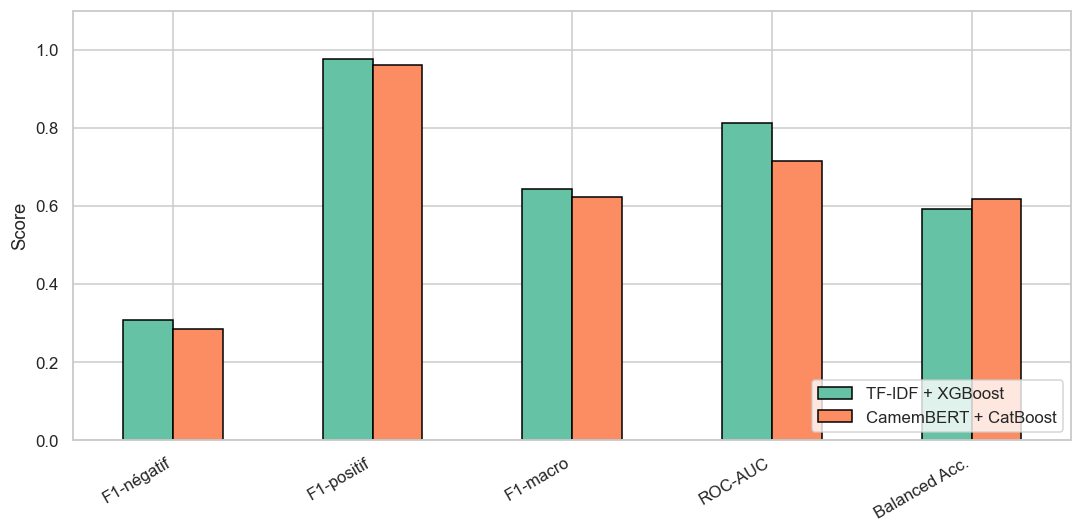

Meilleur pipeline (F1-macro) : TF-IDF + XGBoost


In [156]:
from sklearn.metrics import f1_score as f1

metrics = {
    'Pipeline': ['TF-IDF + XGBoost', 'CamemBERT + CatBoost'],
    'F1-négatif': [
        f1(y, y_pred_cv1, pos_label=0),
        f1(y, y_pred_cv2, pos_label=0),
    ],
    'F1-positif': [
        f1(y, y_pred_cv1, pos_label=1),
        f1(y, y_pred_cv2, pos_label=1),
    ],
    'F1-macro': [
        f1(y, y_pred_cv1, average='macro'),
        f1(y, y_pred_cv2, average='macro'),
    ],
    'ROC-AUC': [
        roc_auc_score(y, y_prob_cv1),
        roc_auc_score(y, y_prob_cv2),
    ],
    'Balanced Acc.': [
        balanced_accuracy_score(y, y_pred_cv1),
        balanced_accuracy_score(y, y_pred_cv2),
    ],
}
comp_df = pd.DataFrame(metrics).set_index('Pipeline').round(4)
display(comp_df.style.background_gradient(cmap='YlGn', axis=0))

# bar chart
comp_df.T.plot(kind='bar', figsize=(10, 5), edgecolor='black')
# plt.title('Comparaison des métriques — CV 5-fold', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_pipeline = comp_df['F1-macro'].idxmax()
print(f'Meilleur pipeline (F1-macro) : {best_pipeline}')


## 6. Prédiction sur le corpus complet

On entraîne le **Pipeline 1 (TF-IDF + XGBoost)** sur les 200 exemples annotés et on prédit les 6 142 lignes restantes.
Le pipeline CamemBERT reste disponible pour l'évaluation comparative (sections 4–5) mais n'est pas utilisé pour la prédiction finale.

In [138]:
# ── Entraînement final sur tout le jeu annoté (Pipeline 1) ──────────────────

tfidf_final = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2),
    min_df=1, sublinear_tf=True,
    stop_words=FRENCH_STOPWORDS       # mots vides français exclus
)
X_train_tfidf = tfidf_final.fit_transform(X_text)

smote_final = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_tr_sm, y_tr_sm = smote_final.fit_resample(X_train_tfidf, y)

xgb_final = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.08,
    scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
)
xgb_final.fit(X_tr_sm, y_tr_sm)
print('Pipeline 1 entraîné (TF-IDF + XGBoost, stopwords FR exclus)')

Pipeline 1 entraîné (TF-IDF + XGBoost, stopwords FR exclus)


In [139]:
# ── Prédiction sur les 6142 lignes non-annotées (Pipeline 1) ────────────────
X_unlabeled = unlabeled['text_clean'].values

X_unl_tfidf = tfidf_final.transform(X_unlabeled)
pred_unl    = xgb_final.predict(X_unl_tfidf)
prob_unl    = xgb_final.predict_proba(X_unl_tfidf)[:, 1]
print('Prédictions terminées')

# ── Assembler le dataset complet ─────────────────────────────────────────────
df_out = df.copy()

# Score de confiance pour les 200 annotés (prédiction du modèle final)
prob_train = xgb_final.predict_proba(X_train_tfidf)[:, 1]

prob_all = np.zeros(len(df_out))
prob_all[df_out['sentiment_president'].notna().values] = prob_train
prob_all[df_out['sentiment_president'].isna().values]  = prob_unl
df_out['prob_positif'] = prob_all

# Sentiment final : gold label si annoté, sinon prédiction Pipeline 1
pred_all = np.zeros(len(df_out), dtype=int)
pred_all[df_out['sentiment_president'].notna().values] = y
pred_all[df_out['sentiment_president'].isna().values]  = pred_unl
df_out['sent_final'] = le.inverse_transform(pred_all)

print('Distribution finale (corpus complet):')
print(df_out['sent_final'].value_counts())
print(f"\nTaux positif global : {(df_out['sent_final']=='positif').mean():.1%}")

Prédictions terminées
Distribution finale (corpus complet):
sent_final
positif    3445
négatif    1419
Name: count, dtype: int64

Taux positif global : 70.8%


## 7. Interprétabilité — Mots-clés discriminants (Pipeline 1)

Les features les plus importantes du modèle TF-IDF + XGBoost révèlent quels termes orientent le classifieur.


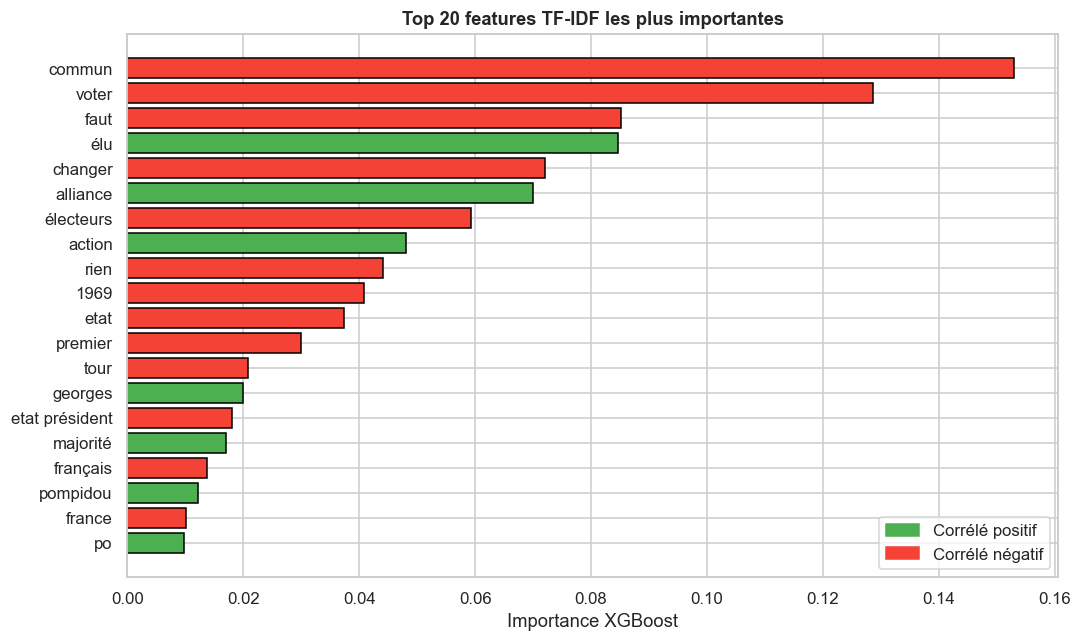

In [140]:
# Importance des features TF-IDF
feat_names   = np.array(tfidf_final.get_feature_names_out())
importances  = xgb_final.feature_importances_
top_n        = 20

top_idx  = np.argsort(importances)[::-1][:top_n]
top_feat = feat_names[top_idx]
top_imp  = importances[top_idx]

# Associer positif/négatif via le signe de la corrélation
sign_color = []
for fi in top_idx:
    feat_vec = X_train_tfidf[:, fi].toarray().ravel()
    corr = np.corrcoef(feat_vec, y)[0, 1]
    sign_color.append('#4CAF50' if corr > 0 else '#F44336')

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_imp[::-1], color=sign_color[::-1], edgecolor='black')
plt.yticks(range(top_n), top_feat[::-1])
plt.xlabel('Importance XGBoost')
plt.title(f'Top {top_n} features TF-IDF les plus importantes', fontweight='bold')
pos_patch = mpatches.Patch(color='#4CAF50', label='Corrélé positif')
neg_patch = mpatches.Patch(color='#F44336', label='Corrélé négatif')
plt.legend(handles=[pos_patch, neg_patch], loc='lower right')
plt.tight_layout()
plt.show()


---
## 8. Analyse des mentions de leaders dans le corpus

> Les analyses suivantes portent sur l'ensemble du corpus (200 labels manuels + 6 142 prédits).


In [141]:
def simplify_parti(s):
    if pd.isna(s) or s.strip() in ('non mentionné', 'inconnu', ''):
        return 'Non mentionné / Inconnu'
    return s.split(';')[0].strip()

def bloc_politique(p):
    p = p.lower()
    if any(x in p for x in ['socialiste', 'communiste', 'lutte ouvri', 'travailleur',
                              'radical de gauche', 'parti socialiste unifié']):
        return 'Gauche'
    if 'front national' in p:
        return 'Extrême droite'
    if any(x in p for x in ['républicain', 'gaulliste', 'démocrate', 'progrès',
                              'udr', 'rpr', 'udf', 'centre', 'radical']):
        return 'Droite / Centre'
    return 'Non classé'

df_out['parti_simple'] = df_out['parti'].apply(simplify_parti)
df_out['bloc'] = df_out['parti_simple'].apply(bloc_politique)

# ── Exclure "Non mentionné / Inconnu" de toutes les visualisations ────────────
df_plot = df_out[df_out['parti_simple'] != 'Non mentionné / Inconnu'].copy()

print('Blocs politiques (hors non mentionné):')
print(df_plot['bloc'].value_counts())
print(f'\nLignes pour les graphiques : {len(df_plot)} / {len(df_out)}')

# Top 10 partis globaux (référence commune à toutes les sections)
TOP10 = df_plot['parti_simple'].value_counts().head(10).index.tolist()
print(f'\nTop 10 partis : {TOP10}')

# Mapping année → président
pres_map = df_out.groupby('annee')['actual_president'].first().to_dict()

Blocs politiques (hors non mentionné):
bloc
Gauche             2726
Droite / Centre     385
Non classé          331
Extrême droite       79
Name: count, dtype: int64

Lignes pour les graphiques : 3521 / 4864

Top 10 partis : ['Parti socialiste', 'Parti communiste français', 'Union des républicains de progrès', 'Union pour la démocratie française', 'Parti socialiste unifié', 'Front national', 'Rassemblement pour la République', 'Alliance républicaine indépendante et libérale', 'Mouvement des radicaux de gauche', 'Lutte ouvrière']


### 8.1 Top 10 partis mentionnant le président — global et par année électorale

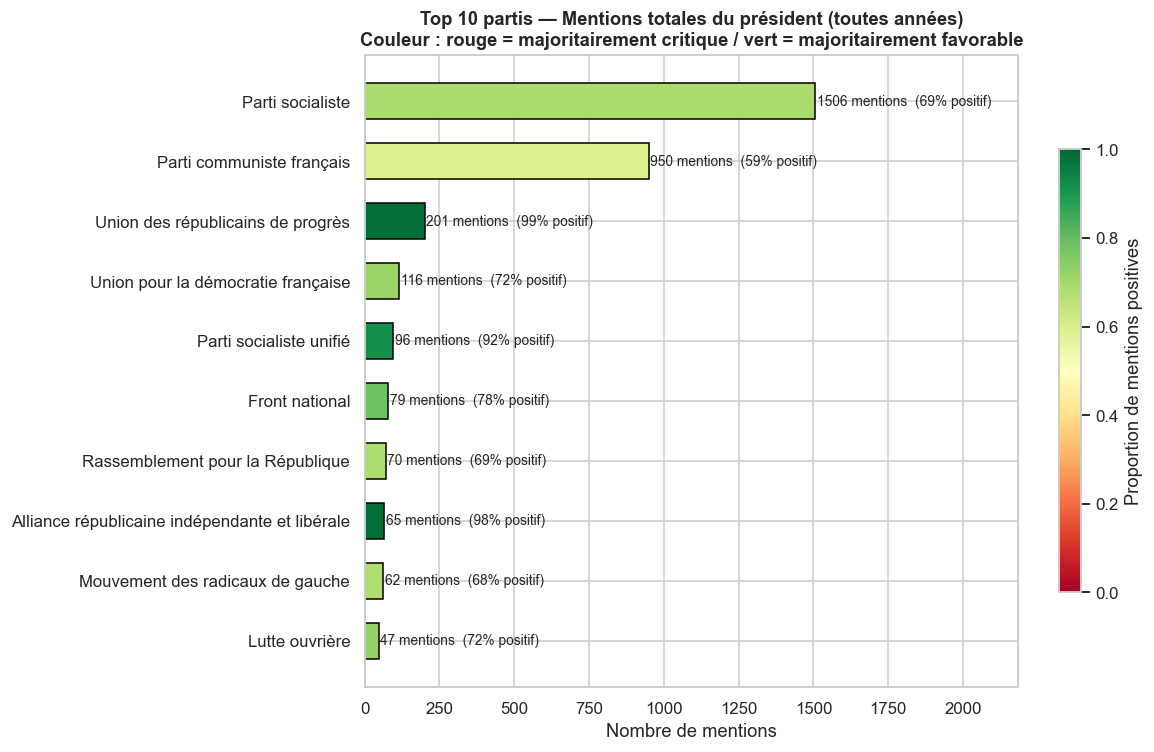

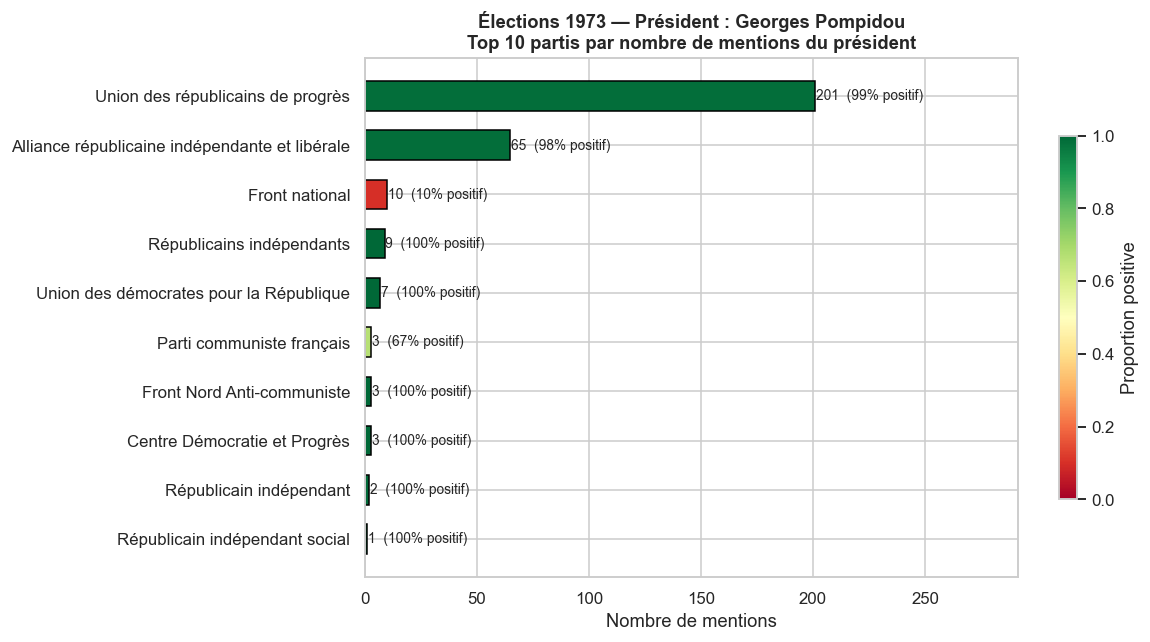

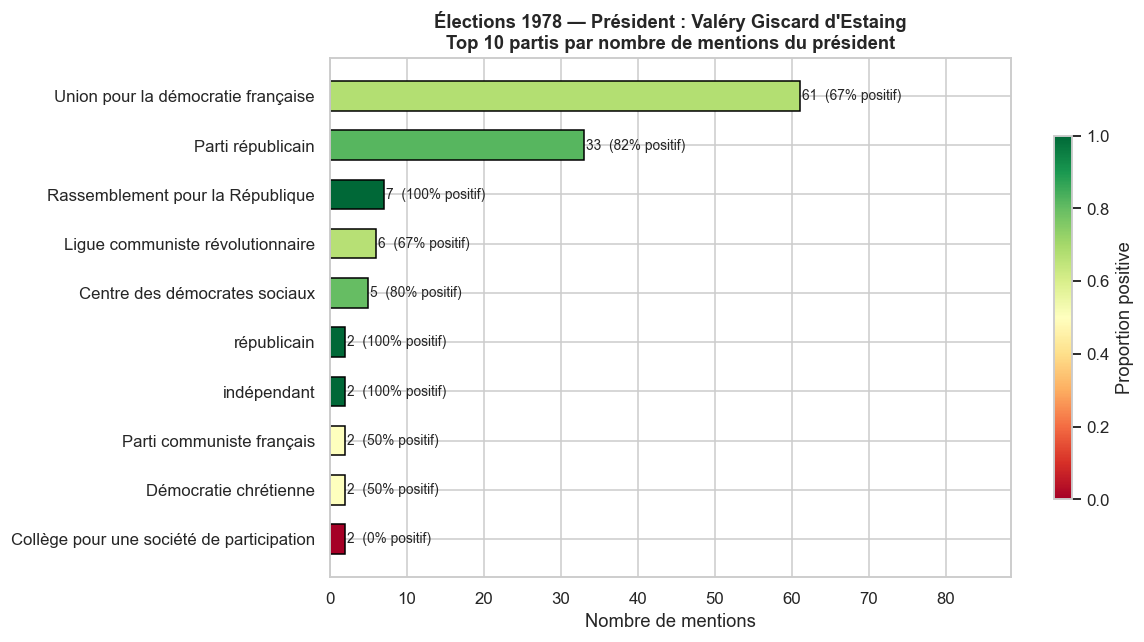

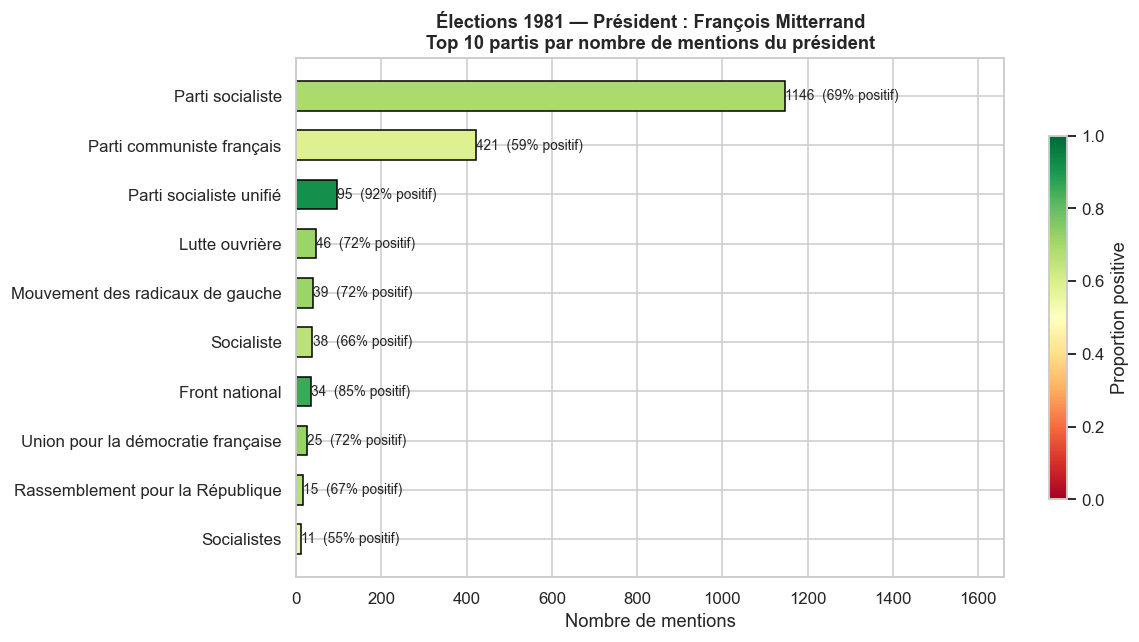

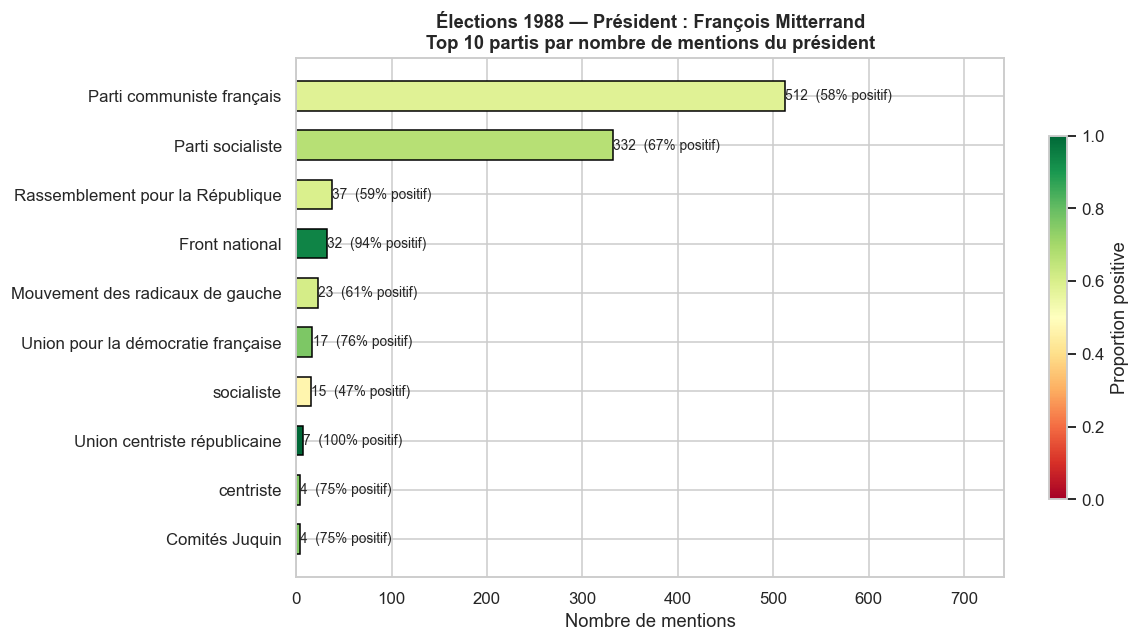

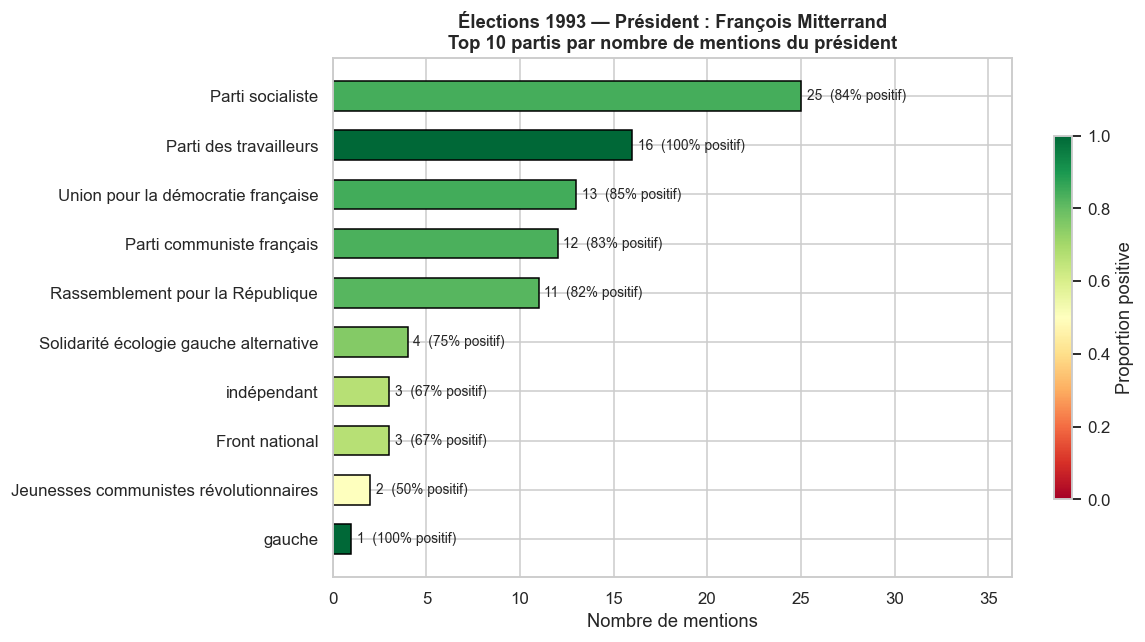

In [142]:
pres_labels = {
    1973: 'Pompidou', 1978: "Giscard d'E.",
    1981: 'Mitterrand I', 1988: 'Mitterrand II', 1993: 'Mitterrand III'
}

# ── Top 10 partis — mentions totales (toutes années confondues) ───────────────
stats_global = (
    df_plot[df_plot['parti_simple'].isin(TOP10)]
    .groupby('parti_simple')
    .agg(mentions=('sent_final', 'count'),
         taux_positif=('sent_final', lambda x: (x == 'positif').mean()))
    .sort_values('mentions', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors_g = [plt.cm.RdYlGn(v) for v in stats_global['taux_positif']]
ax.barh(stats_global.index, stats_global['mentions'], color=colors_g, edgecolor='black', height=0.6)
for i, (nb, tx) in enumerate(zip(stats_global['mentions'], stats_global['taux_positif'])):
    ax.text(nb + 5, i, f'{nb} mentions  ({tx:.0%} positif)', va='center', fontsize=9)
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
plt.colorbar(sm, ax=ax, label='Proportion de mentions positives', shrink=0.7)
ax.set_title('Top 10 partis — Mentions totales du président (toutes années)\n'
             'Couleur : rouge = majoritairement critique / vert = majoritairement favorable',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Nombre de mentions')
ax.set_xlim(0, stats_global['mentions'].max() * 1.45)
plt.tight_layout()
plt.show()

# ── Top 10 partis par année — une figure par élection ────────────────────────
for yr in sorted(df_plot['annee'].unique()):
    df_yr   = df_plot[df_plot['annee'] == yr]
    top_yr  = df_yr['parti_simple'].value_counts().head(10).index

    stats_yr = (
        df_yr[df_yr['parti_simple'].isin(top_yr)]
        .groupby('parti_simple')
        .agg(mentions=('sent_final', 'count'),
             taux_positif=('sent_final', lambda x: (x == 'positif').mean()))
        .sort_values('mentions', ascending=True)
    )

    pres    = pres_map.get(yr, '')
    colors_yr = [plt.cm.RdYlGn(v) for v in stats_yr['taux_positif']]

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(stats_yr.index, stats_yr['mentions'], color=colors_yr, edgecolor='black', height=0.6)
    for i, (nb, tx) in enumerate(zip(stats_yr['mentions'], stats_yr['taux_positif'])):
        ax.text(nb + 0.3, i, f'{nb}  ({tx:.0%} positif)', va='center', fontsize=9)
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
    plt.colorbar(sm, ax=ax, label='Proportion positive', shrink=0.7)
    ax.set_title(f'Élections {yr} — Président : {pres}\n'
                 f'Top 10 partis par nombre de mentions du président',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Nombre de mentions')
    ax.set_xlim(0, stats_yr['mentions'].max() * 1.45)
    plt.tight_layout()
    plt.show()

### 8.2 Proportions de mentions positives par orientation politique

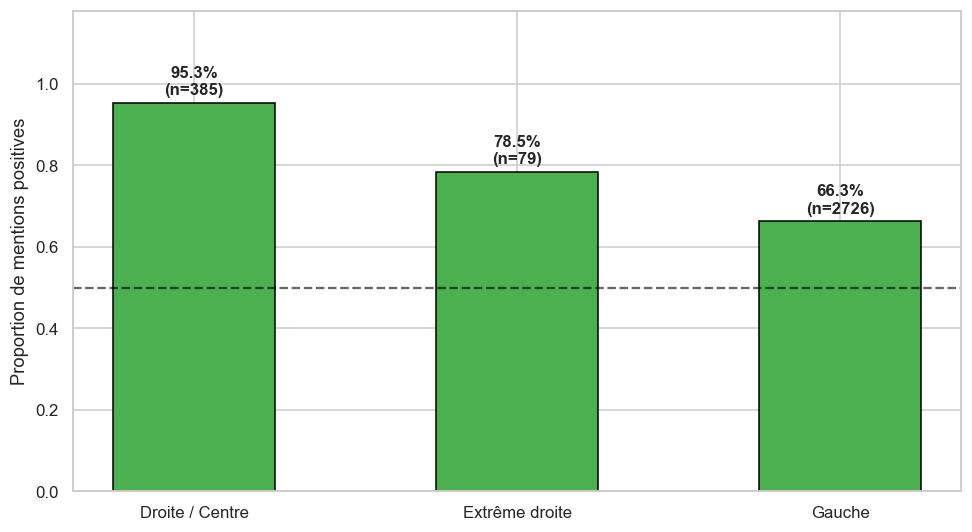

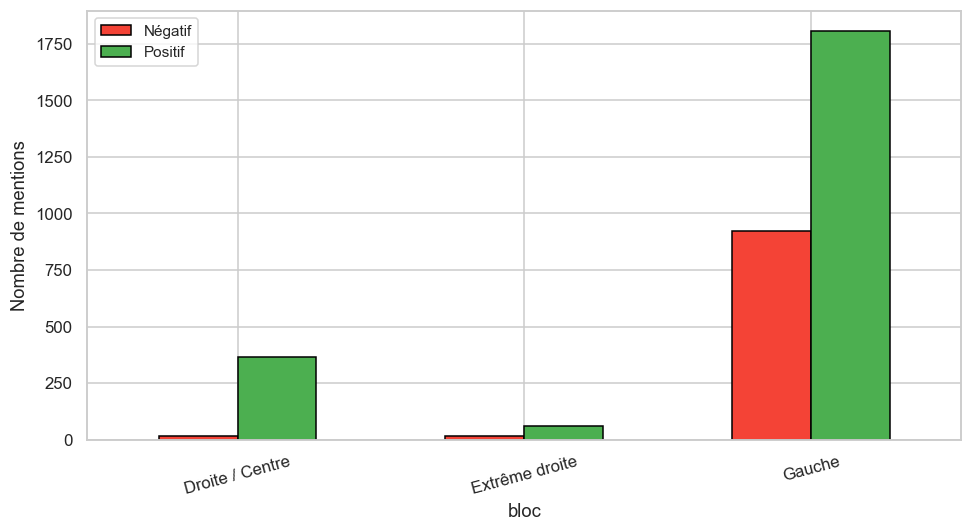

In [157]:
df_bloc = df_plot[df_plot['bloc'] != 'Non classé'].copy()

bloc_stats = (
    df_bloc.groupby('bloc')
    .agg(total=('sent_final', 'count'),
         positif=('sent_final', lambda x: (x == 'positif').sum()))
    .assign(taux=lambda d: d['positif'] / d['total'])
    .sort_values('taux', ascending=False)
)

# ── Graphique 1 : proportion positive par bloc ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_b = ['#4CAF50' if v > 0.5 else '#F44336' for v in bloc_stats['taux']]
ax.bar(bloc_stats.index, bloc_stats['taux'], color=colors_b, edgecolor='black', width=0.5)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
for i, (tx, nb) in enumerate(zip(bloc_stats['taux'], bloc_stats['total'])):
    ax.text(i, tx + 0.02, f'{tx:.1%}\n(n={nb})', ha='center', fontweight='bold', fontsize=11)
# ax.set_title('Proportion de mentions positives du président\npar orientation politique',
#              fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion de mentions positives')
ax.set_ylim(0, 1.18)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

# ── Graphique 2 : volume positif / négatif par bloc ──────────────────────────
bloc_abs = df_bloc.groupby(['bloc', 'sent_final']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
bloc_abs.plot(kind='bar', ax=ax, color=['#F44336', '#4CAF50'], edgecolor='black', width=0.55)
# ax.set_title('Volume absolu de mentions positives / négatives\npar orientation politique',
#              fontweight='bold', fontsize=13)
ax.set_ylabel('Nombre de mentions')
ax.tick_params(axis='x', rotation=15)
ax.legend(['Négatif', 'Positif'], fontsize=10)
plt.tight_layout()
plt.show()

### 8.4 Proportion de mentions positives par année électorale

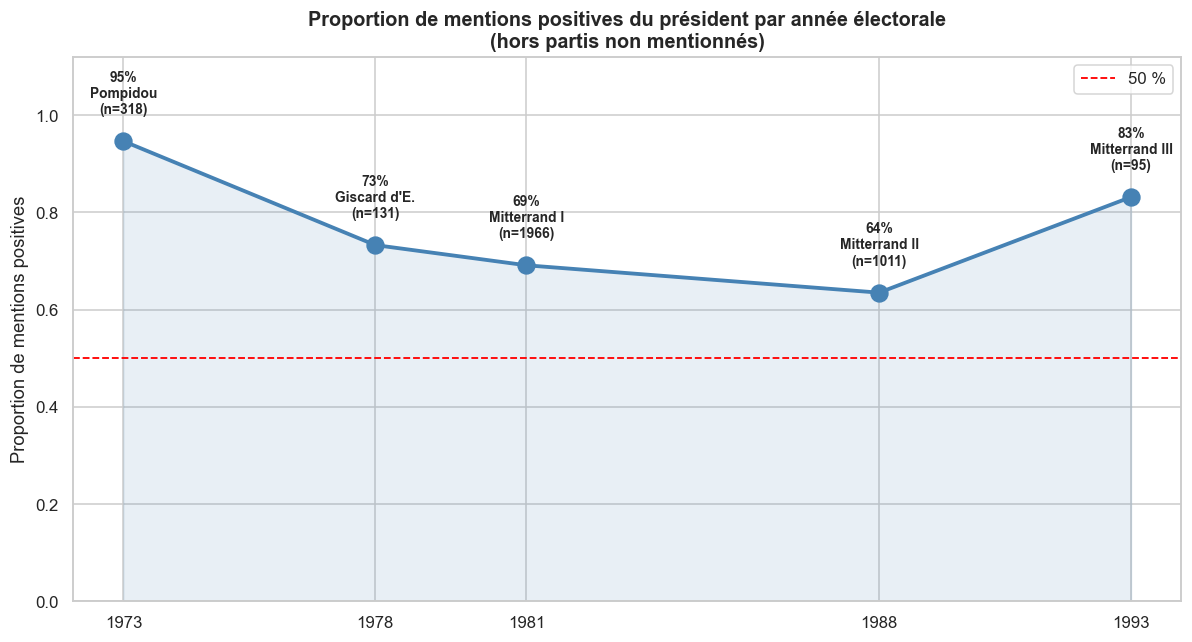

In [145]:
year_stats = (
    df_plot.groupby('annee')
    .agg(total=('sent_final', 'count'),
         positif=('sent_final', lambda x: (x == 'positif').sum()))
    .assign(taux=lambda d: d['positif'] / d['total'])
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(year_stats.index, year_stats['taux'], marker='o', markersize=11,
        linewidth=2.5, color='steelblue', zorder=3)
ax.fill_between(year_stats.index, year_stats['taux'], alpha=0.12, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='50 %')
for yr, row in year_stats.iterrows():
    pres = pres_labels.get(yr, '')
    ax.annotate(f"{row['taux']:.0%}\n{pres}\n(n={int(row['total'])})",
                (yr, row['taux']), textcoords='offset points',
                xytext=(0, 18), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Proportion de mentions positives du président par année électorale\n(hors partis non mentionnés)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion de mentions positives')
ax.set_ylim(0, 1.12)
ax.set_xticks(year_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

### 8.6 Mentions et popularité par président en exercice

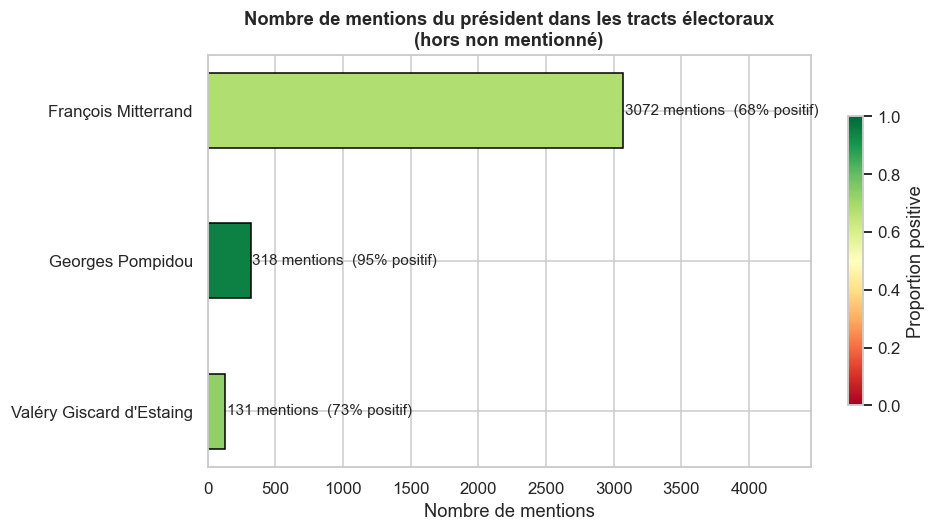

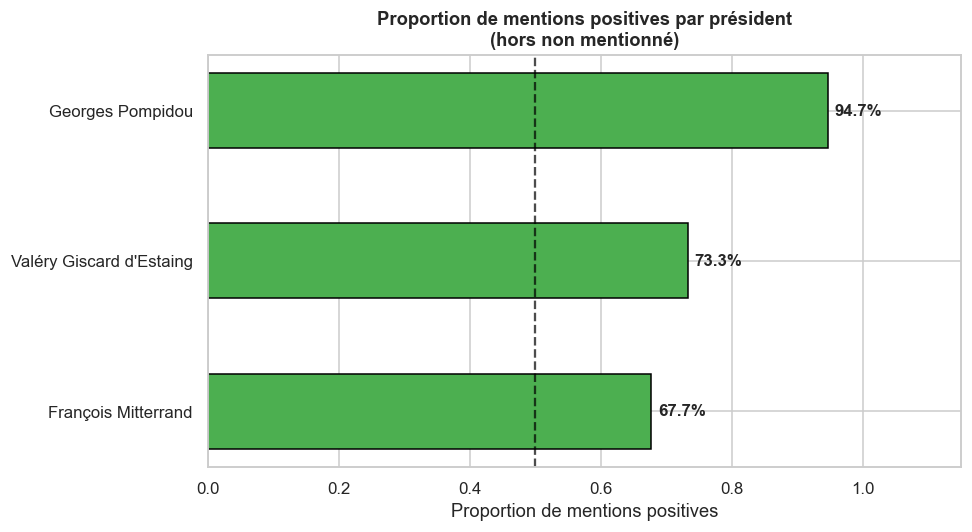

In [147]:
pres_stats = (
    df_plot.groupby('actual_president')
    .agg(total=('sent_final', 'count'),
         taux_positif=('sent_final', lambda x: (x == 'positif').mean()))
    .sort_values('total', ascending=True)
)

# ── Graphique 1 : nombre de mentions par président ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_pr = [plt.cm.RdYlGn(v) for v in pres_stats['taux_positif']]
ax.barh(pres_stats.index, pres_stats['total'], color=colors_pr, edgecolor='black', height=0.5)
for i, (nb, tx) in enumerate(zip(pres_stats['total'], pres_stats['taux_positif'])):
    ax.text(nb + 10, i, f'{nb} mentions  ({tx:.0%} positif)', va='center', fontsize=10)
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
plt.colorbar(sm, ax=ax, label='Proportion positive', shrink=0.7)
ax.set_title('Nombre de mentions du président dans les tracts électoraux\n(hors non mentionné)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Nombre de mentions')
ax.set_xlim(0, pres_stats['total'].max() * 1.45)
plt.tight_layout()
plt.show()

# ── Graphique 2 : proportion positive par président ───────────────────────────
pres_by_tx = pres_stats.sort_values('taux_positif', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_pr2 = ['#4CAF50' if v > 0.5 else '#F44336' for v in pres_by_tx['taux_positif']]
ax.barh(pres_by_tx.index, pres_by_tx['taux_positif'], color=colors_pr2, edgecolor='black', height=0.5)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
for i, tx in enumerate(pres_by_tx['taux_positif']):
    ax.text(tx + 0.01, i, f'{tx:.1%}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Proportion de mentions positives par président\n(hors non mentionné)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Proportion de mentions positives')
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.show()

### 8.8 Popularité présidentielle par ère — évolution et soutiens

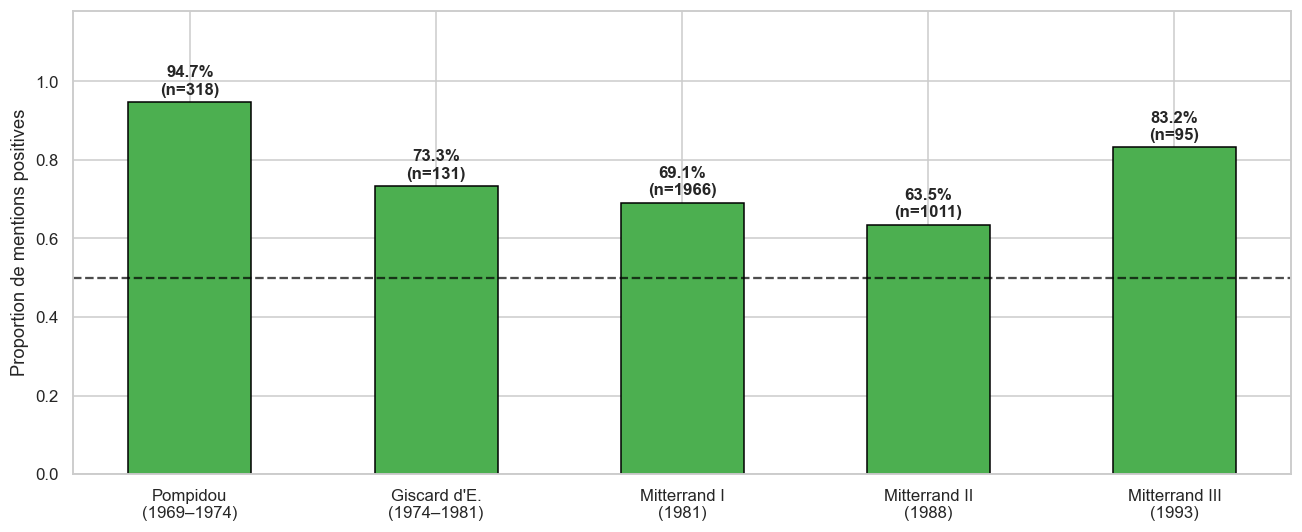

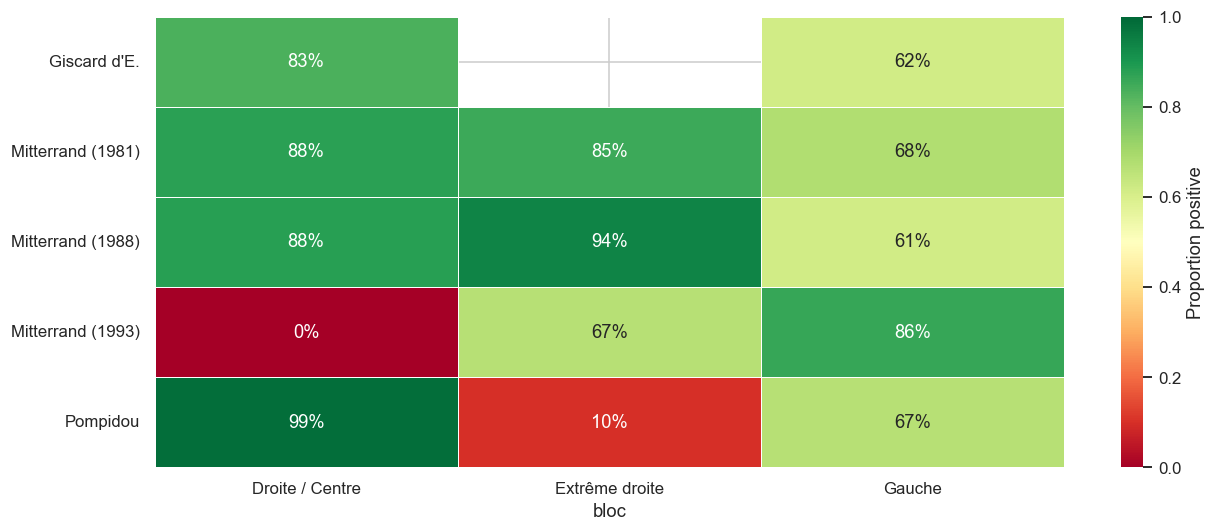

In [160]:
eras = [
    {'label': 'Pompidou\n(1969–1974)',    'president': 'Georges Pompidou',           'annees': [1973]},
    {'label': "Giscard d'E.\n(1974–1981)",'president': "Valéry Giscard d'Estaing",   'annees': [1978]},
    {'label': 'Mitterrand I\n(1981)',      'president': 'François Mitterrand',         'annees': [1981]},
    {'label': 'Mitterrand II\n(1988)',     'president': 'François Mitterrand',         'annees': [1988]},
    {'label': 'Mitterrand III\n(1993)',    'president': 'François Mitterrand',         'annees': [1993]},
]

era_rows = []
for era in eras:
    sub = df_plot[
        (df_plot['actual_president'] == era['president']) &
        (df_plot['annee'].isin(era['annees']))
    ]
    if len(sub) == 0:
        continue
    era_rows.append({
        'ère':          era['label'],
        'total':        len(sub),
        'taux_positif': (sub['sent_final'] == 'positif').mean(),
    })
era_df = pd.DataFrame(era_rows)

# ── Graphique 1 : popularité par ère présidentielle ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors_era = ['#4CAF50' if v > 0.5 else '#F44336' for v in era_df['taux_positif']]
ax.bar(era_df['ère'], era_df['taux_positif'], color=colors_era, edgecolor='black', width=0.5)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
for i, (tx, nb) in enumerate(zip(era_df['taux_positif'], era_df['total'])):
    ax.text(i, tx + 0.02, f'{tx:.1%}\n(n={nb})', ha='center', fontweight='bold', fontsize=11)
# ax.set_title("Popularité présidentielle dans les tracts électoraux\n"
#              "(proportion de mentions positives par ère)",
#              fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion de mentions positives')
ax.set_ylim(0, 1.18)
plt.tight_layout()
plt.show()


# ── Graphique 3 : qui soutient qui ? — bloc × ère présidentielle ─────────────
df_bloc_era = df_plot[df_plot['bloc'] != 'Non classé'].copy()
df_bloc_era['ère'] = df_bloc_era.apply(
    lambda r: {
        'Georges Pompidou':          'Pompidou',
        "Valéry Giscard d'Estaing":  "Giscard d'E.",
        'François Mitterrand':        f"Mitterrand ({r['annee']})"
    }.get(r['actual_president'], r['actual_president']),
    axis=1
)
pivot_soutien = (
    df_bloc_era.groupby(['ère', 'bloc'])['sent_final']
    .apply(lambda x: (x == 'positif').mean())
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_soutien, annot=True, fmt='.0%', cmap='RdYlGn', center=0.5,
             vmin=0, vmax=1, linewidths=0.5, ax=ax,
             cbar_kws={'label': 'Proportion positive'})
# ax.set_title("Soutiens au président selon le bloc politique × ère présidentielle\n"
#              "(proportion de mentions positives — hors non classé)",
#              fontweight='bold', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 8.9 Évolution du taux de mentions positives — 6 grands partis (1973–1993)

In [ ]:
SIX_PARTIS = df_plot['parti_simple'].value_counts().head(6).index.tolist()

PARTY_SHORT = {
    'Parti socialiste':                               'PS',
    'Parti communiste français':                      'PCF',
    'Union des républicains de progrès':              'URP (gaulliste)',
    'Union pour la démocratie française':             'UDF',
    'Parti socialiste unifié':                        'PSU',
    'Front national':                                 'FN',
    'Rassemblement pour la République':               'RPR',
    'Alliance républicaine indépendante et libérale': 'ARIL',
    'Mouvement des radicaux de gauche':               'MRG',
    'Lutte ouvrière':                                 'LO',
}

PARTY_COLORS = {
    'Parti socialiste':                               '#E74C3C',
    'Parti communiste français':                      '#922B21',
    'Union des républicains de progrès':              '#2980B9',
    'Union pour la démocratie française':             '#27AE60',
    'Parti socialiste unifié':                        '#E67E22',
    'Front national':                                 '#1A1A2E',
    'Rassemblement pour la République':               '#1ABC9C',
    'Alliance républicaine indépendante et libérale': '#9B59B6',
    'Mouvement des radicaux de gauche':               '#F39C12',
    'Lutte ouvrière':                                 '#BDC3C7',
}

ANNEES     = sorted(df_plot['annee'].unique())
ANNEES_STR = [str(a) for a in ANNEES]
xs         = list(range(len(ANNEES)))

# Taux positif et volume par parti × année
pivot_pos = (
    df_plot[df_plot['parti_simple'].isin(SIX_PARTIS)]
    .groupby(['annee', 'parti_simple'])['sent_final']
    .apply(lambda x: (x == 'positif').mean())
    .unstack()
)
pivot_n = (
    df_plot[df_plot['parti_simple'].isin(SIX_PARTIS)]
    .groupby(['annee', 'parti_simple'])['sent_final']
    .count()
    .unstack()
)

# Masquer les cellules avec < 5 mentions (trop peu représentatives)
MIN_MENTIONS = 5
pivot_plot = pivot_pos.where(pivot_n >= MIN_MENTIONS)

fig, ax = plt.subplots(figsize=(14, 7))

# Fond coloré par ère présidentielle
ax.axvspan(-0.45, 0.45, color='#FFF9C4', alpha=0.55, zorder=0)
ax.axvspan( 0.55, 1.45, color='#E1F5FE', alpha=0.55, zorder=0)
ax.axvspan( 1.55, 4.45, color='#E8F5E9', alpha=0.55, zorder=0)

# Étiquettes présidents (en haut)
for x_pos, label, col_t in [
    (0,   'Pompidou',     '#7D6608'),
    (1,   "Giscard d'E.", '#1565C0'),
    (2.5, 'Mitterrand',   '#1B5E20'),
]:
    ax.text(x_pos, 1.13, label, ha='center', va='top', fontsize=9.5,
             color=col_t, fontstyle='italic', fontweight='bold')

# 6 courbes
for parti in SIX_PARTIS:
    if parti not in pivot_plot.columns:
        continue
    short = PARTY_SHORT.get(parti, parti)
    color = PARTY_COLORS.get(parti, None)
    ys    = [pivot_plot[parti].get(a, np.nan) for a in ANNEES]
    ns    = pivot_n.get(parti, pd.Series(dtype=float))

    ax.plot(xs, ys, marker='o', markersize=9, linewidth=2.3,
             label=short, color=color, zorder=3)

    for xi, (a, v) in enumerate(zip(ANNEES, ys)):
        if pd.isna(v):
            continue
        n = int(ns.get(a, 0))
        ax.annotate(f'{v:.0%}\n(n={n})', (xi, v), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=7.5,
                     color=color, fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.3, alpha=0.6)

ax.set_title('Évolution du taux de mentions positives du président\n'
             'par grand parti politique (1973–1993)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion de mentions positives')
ax.set_ylim(0, 1.22)
ax.set_xticks(xs)
ax.set_xticklabels(ANNEES_STR, fontsize=11)
ax.legend(loc='upper right', fontsize=10, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f'6 partis sélectionnés : {[PARTY_SHORT.get(p, p) for p in SIX_PARTIS]}')
print('\nTaux positif par parti × année (— = moins de 5 mentions)')
display(pivot_plot.applymap(lambda v: f'{v:.0%}' if not pd.isna(v) else '—'))

## 9. Sauvegarde des résultats

In [153]:
OUTPUT_PATH = '../../data/results/output_best_model/leaders_mentions_classified.xlsx'
df_out[['annee', 'departement', 'parti', 'parti_simple', 'bloc',
         'actual_president', 'entite', 'text', 'text_clean',
         'sentiment_president', 'sent_final', 'prob_positif']].to_excel(
    OUTPUT_PATH, index=False
)
print(f'Résultats sauvegardés : {OUTPUT_PATH}')
print(f'Lignes exportées      : {len(df_out)}')


Résultats sauvegardés : ../../data/results/output_best_model/leaders_mentions_classified.xlsx
Lignes exportées      : 4864
